In [57]:
#Imports

import os
import random
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import redivis
import tensorflow as tf
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    hinge_loss,
    log_loss,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

SEED = 12345
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


> **Note:** This setup script only needs to be **run once**. It loads and downloads all the data into your local folder, which takes approximately **45 minutes** to complete.

```python
from pathlib import Path
import re
import pandas as pd
import redivis

# NOTE: This script loads all the dataset files and only needs to be run once.
# Expect the download process to take around 45 minutes to complete.

labels_dir = Path(".")
out_dir = Path("./StanfordMRNet")

dataset = redivis.organization("AIMI").dataset("mrnet_knee_mri_s:4a2c")

for split in ["train", "valid"]:
    labels_path = labels_dir / f"{split}_acl_labels.csv"
    if not labels_path.exists():
        raise FileNotFoundError(f"Missing {labels_path}")

    labels = pd.read_csv(labels_path)
    id_col = "volumeFilename" if "volumeFilename" in labels.columns else labels.columns[0]

    keep_ids = {
        int(match.group())
        for value in labels[id_col].dropna()
        if (match := re.search(r"\d+", str(value)))
    }

    split_dir = out_dir / split
    split_dir.mkdir(parents=True, exist_ok=True)

    table = dataset.table(split)
    df = table.to_pandas_dataframe()

    for _, row in df.iterrows():
        file_name = str(row["file_name"])
        match = re.search(r"\d+", Path(file_name).stem)

        if not match or int(match.group()) not in keep_ids:
            continue

        file_path = split_dir / file_name
        if not file_path.exists():
            file_path.parent.mkdir(parents=True, exist_ok=True)
            table.file(row["file_id"]).download(str(file_path))

In [58]:
#Mapping

def to_binary_label(raw_label):
    if pd.isna(raw_label):
        return None
    v = int(raw_label)
    return 1 if v == 2 else v

def extract_case_id(value):
    m = re.search(r"\d+", str(value))
    return int(m.group()) if m else None

def infer_columns(df):
    cols = list(df.columns)
    id_candidates = ["volumeFilename", "file_name", "filename", "case", "case_id", "id"]
    lbl_candidates = ["aclDiagnosis", "acl_label", "label", "acl"]

    id_col = next((c for c in id_candidates if c in cols), cols[0])
    label_col = next((c for c in lbl_candidates if c in cols), cols[-1])
    return id_col, label_col

def load_split_label_map(csv_path):
    df = pd.read_csv(csv_path)
    id_col, label_col = infer_columns(df)

    return {
        cid: lbl
        for _, row in df.iterrows()
        if (cid := extract_case_id(row[id_col])) is not None
        if (lbl := to_binary_label(row[label_col])) is not None
    }

def map_paths_to_labels(paths, label_map):
    return [
        (p, label_map[cid])
        for p in paths
        if (cid := extract_case_id(p.stem)) in label_map
    ]

sagittal_dirs = [Path("StanfordMRNet/train/sagittal"), Path("StanfordMRNet/valid/sagittal")]
all_sag_paths = sorted(p for d in sagittal_dirs for p in d.glob("*.npy"))

label_map = {}
label_map.update(load_split_label_map("train_acl_labels.csv"))
label_map.update(load_split_label_map("valid_acl_labels.csv"))

all_mapped = map_paths_to_labels(all_sag_paths, label_map)
label_names = {0: "Normal", 1: "Torn"}

split_seed = int(time.time() * 1000) % (2**32)
train_mapped, valid_mapped = train_test_split(
    all_mapped,
    test_size=0.2,
    stratify=[y for _, y in all_mapped],
    random_state=split_seed,
)

print(f"Total sagittal files: {len(all_sag_paths)}, labeled: {len(all_mapped)}")
print(f"Train: {len(train_mapped)}, Valid: {len(valid_mapped)} (split_seed={split_seed})")
print("Train class counts:", dict(Counter(y for _, y in train_mapped)))
print("Valid class counts:", dict(Counter(y for _, y in valid_mapped)))


Total sagittal files: 1248, labeled: 1248
Train: 998, Valid: 250 (split_seed=1167420849)
Train class counts: {0: 788, 1: 210}
Valid class counts: {0: 198, 1: 52}


In [59]:
#Preprocessing

MAX_SAMPLES = 400
IMG_SIZE = (64, 64)
hog_params = {"orientations": 9, "pixels_per_cell": (8, 8), "cells_per_block": (2, 2)}

def load_volume(path):
    return np.load(path, allow_pickle=True)

def prepare_volume_inputs(volume, image_size):
    volume_arr = np.asarray(volume)

    if volume_arr.ndim == 3 and volume_arr.shape[0] >= 3:
        center_idx = volume_arr.shape[0] // 2
        slice_indices = [max(0, center_idx - 1), center_idx, min(volume_arr.shape[0] - 1, center_idx + 1)]
        channels = []
        for slice_index in slice_indices:
            slice_image = volume_arr[slice_index]
            if slice_image.ndim == 3:
                slice_image = rgb2gray(slice_image)
            slice_resized = resize(slice_image, image_size, anti_aliasing=True)
            channels.append(slice_resized.astype(np.float32))
        return channels[1], np.stack(channels, axis=-1)

    center_slice = volume_arr[volume_arr.shape[0] // 2] if volume_arr.ndim == 3 else volume_arr
    if center_slice.ndim == 3:
        center_slice = rgb2gray(center_slice)
    center_slice = resize(center_slice, image_size, anti_aliasing=True)
    return center_slice, np.stack([center_slice.astype(np.float32)] * 3, axis=-1)

def build_split_arrays(mapped_split, cache_path=None, max_samples=None):
    if cache_path and Path(cache_path).exists():
        d = np.load(cache_path, allow_pickle=True)
        return d["X_hog"], d["X_images"], d["y_labels"]

    rng = random.Random(SEED)
    by_label = {}
    for p, y in mapped_split:
        by_label.setdefault(y, []).append(p)

    selected = []
    if max_samples is None:
        for y in sorted(by_label):
            selected.extend([(p, y) for p in by_label[y]])
    else:
        n_classes = max(1, len(by_label))
        per_class = max(1, max_samples // n_classes)
        for y in sorted(by_label):
            picks = by_label[y]
            take = min(len(picks), per_class)
            chosen = rng.sample(picks, take) if len(picks) > take else picks
            selected.extend([(p, y) for p in chosen])

    hog_features_list, image_tensors_list, labels_list = [], [], []
    t0 = time.time()
    for p, y in selected:
        vol = load_volume(p)
        slice_resized, cnn_img = prepare_volume_inputs(vol, IMG_SIZE)

        hog_descriptor = hog(
            (slice_resized * 255).astype(np.uint8),
            orientations=hog_params["orientations"],
            pixels_per_cell=hog_params["pixels_per_cell"],
            cells_per_block=hog_params["cells_per_block"],
            visualize=False,
            feature_vector=True,
        )
        hog_features_list.append(hog_descriptor)
        image_tensors_list.append(cnn_img)
        labels_list.append(y)

    X_hog = np.vstack(hog_features_list)
    X_images = np.stack(image_tensors_list)
    y_labels = np.array(labels_list)

    if cache_path:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_path, X_hog=X_hog, X_images=X_images, y_labels=y_labels)

    print(f"Built {len(y_labels)} samples in {time.time()-t0:.1f}s from {cache_path}")
    return X_hog, X_images, y_labels

X_hog_train, X_images_train, y_images_train = build_split_arrays(
    train_mapped, cache_path=None, max_samples=MAX_SAMPLES
)
X_hog_test, X_images_val, y_images_val = build_split_arrays(
    valid_mapped, cache_path=None, max_samples=None
)

print("Train labels:", dict(Counter(y_images_train.tolist())))
print("Valid labels:", dict(Counter(y_images_val.tolist())))


Built 400 samples in 1.5s from None
Built 250 samples in 0.9s from None
Train labels: {0: 200, 1: 200}
Valid labels: {0: 198, 1: 52}


In [60]:
#Model architecture

def build_svm(learning_rate=1e-3):
    return SGDClassifier(loss="hinge", random_state=SEED, learning_rate="constant", eta0=learning_rate)

def build_logr(learning_rate=1e-3):
    return SGDClassifier(loss="log_loss", random_state=SEED, learning_rate="constant", eta0=learning_rate)

def build_cnn(input_shape, learning_rate=1e-4):
    cnn_model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return cnn_model


Class weights: {0: 1.0, 1: 1.0}

Training CNN...
Epoch 1/25
25/25 - 1s - 38ms/step - accuracy: 0.4825 - loss: 0.6974 - val_accuracy: 0.6080 - val_loss: 0.6834
Epoch 2/25
25/25 - 0s - 13ms/step - accuracy: 0.6325 - loss: 0.6671 - val_accuracy: 0.7320 - val_loss: 0.6415
Epoch 3/25
25/25 - 0s - 13ms/step - accuracy: 0.6650 - loss: 0.6399 - val_accuracy: 0.7280 - val_loss: 0.6031
Epoch 4/25
25/25 - 0s - 14ms/step - accuracy: 0.7225 - loss: 0.5889 - val_accuracy: 0.7440 - val_loss: 0.5802
Epoch 5/25
25/25 - 0s - 13ms/step - accuracy: 0.7175 - loss: 0.5632 - val_accuracy: 0.7320 - val_loss: 0.5726
Epoch 6/25
25/25 - 0s - 13ms/step - accuracy: 0.7500 - loss: 0.5447 - val_accuracy: 0.7240 - val_loss: 0.5752
Epoch 7/25
25/25 - 0s - 13ms/step - accuracy: 0.7875 - loss: 0.5110 - val_accuracy: 0.7040 - val_loss: 0.5870
Epoch 8/25
25/25 - 0s - 12ms/step - accuracy: 0.7800 - loss: 0.5084 - val_accuracy: 0.7400 - val_loss: 0.5342
Epoch 9/25
25/25 - 0s - 12ms/step - accuracy: 0.8025 - loss: 0.4753 - v

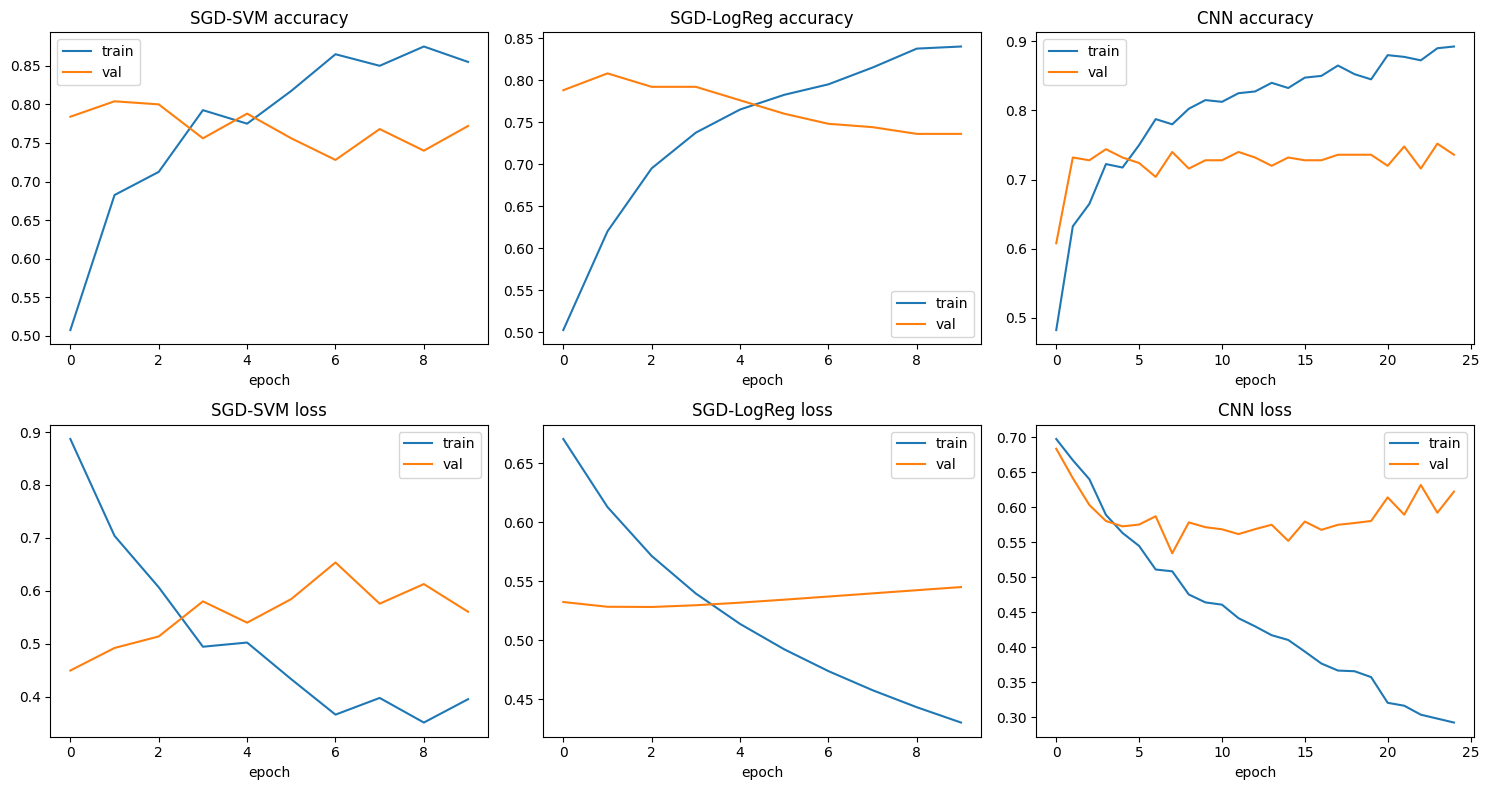

In [ ]:
#Training

EPOCHS = 25
SGD_EPOCHS = 10
LEARNING_RATE = 1e-4
SGD_LEARNING_RATE = 0.01

X_images_train = np.clip(X_images_train, 0.0, 1.0)
X_images_val = np.clip(X_images_val, 0.0, 1.0)

class_counts = Counter(y_images_train.tolist())
classes = np.array(sorted(class_counts.keys()))
total = sum(class_counts.values())
class_weight_dict = {
    int(c): total / (len(classes) * class_counts[int(c)])
    for c in classes
}
sample_weight_train = np.array([class_weight_dict[int(y)] for y in y_images_train], dtype=np.float32)
print("Class weights:", class_weight_dict)

sgd_svm = build_svm(learning_rate=SGD_LEARNING_RATE)
svm_history = {"acc": [], "val_acc": [], "loss": [], "val_loss": []}
for _ in range(SGD_EPOCHS):
    sgd_svm.partial_fit(
        X_hog_train, y_images_train, classes=np.array([0, 1]), sample_weight=sample_weight_train,
    )
    svm_history["acc"].append(accuracy_score(y_images_train, sgd_svm.predict(X_hog_train)))
    svm_history["val_acc"].append(accuracy_score(y_images_val, sgd_svm.predict(X_hog_test)))
    svm_history["loss"].append(hinge_loss(y_images_train, sgd_svm.decision_function(X_hog_train)))
    svm_history["val_loss"].append(hinge_loss(y_images_val, sgd_svm.decision_function(X_hog_test)))

sgd_logr = build_logr(learning_rate=SGD_LEARNING_RATE)
logr_history = {"acc": [], "val_acc": [], "loss": [], "val_loss": []}
for _ in range(SGD_EPOCHS):
    sgd_logr.partial_fit(
        X_hog_train, y_images_train, classes=np.array([0, 1]), sample_weight=sample_weight_train,
    )
    logr_history["acc"].append(accuracy_score(y_images_train, sgd_logr.predict(X_hog_train)))
    logr_history["val_acc"].append(accuracy_score(y_images_val, sgd_logr.predict(X_hog_test)))
    logr_history["loss"].append(log_loss(y_images_train, sgd_logr.predict_proba(X_hog_train)))
    logr_history["val_loss"].append(log_loss(y_images_val, sgd_logr.predict_proba(X_hog_test)))

model = build_cnn(X_images_train.shape[1:], learning_rate=LEARNING_RATE)
print("\nTraining CNN...")
cnn_history = model.fit(
    X_images_train,
    y_images_train,
    epochs=EPOCHS,
    batch_size=16,
    validation_data=(X_images_val, y_images_val),
    verbose=2,
    class_weight=class_weight_dict,
)

curve_specs = [
    ("SGD-SVM", svm_history["acc"], svm_history["val_acc"], svm_history["loss"], svm_history["val_loss"]),
    ("SGD-LogReg", logr_history["acc"], logr_history["val_acc"], logr_history["loss"], logr_history["val_loss"]),
    ("CNN", cnn_history.history["accuracy"], cnn_history.history["val_accuracy"], cnn_history.history["loss"], cnn_history.history["val_loss"]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (name, acc, val_acc, loss, val_loss) in enumerate(curve_specs):
    axes[0, col].plot(acc, label="train")
    axes[0, col].plot(val_acc, label="val")
    axes[0, col].set_title(f"{name} accuracy")
    axes[0, col].set_xlabel("epoch")
    axes[0, col].legend()

    axes[1, col].plot(loss, label="train")
    axes[1, col].plot(val_loss, label="val")
    axes[1, col].set_title(f"{name} loss")
    axes[1, col].set_xlabel("epoch")
    axes[1, col].legend()

plt.tight_layout()
plt.show()


In [63]:
#Validation

from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5

kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
svm_acc, logr_acc, cnn_acc = [], [], []

oof_true = np.empty_like(y_images_train)
oof_pred_svm = np.empty_like(y_images_train)
oof_pred_logr = np.empty_like(y_images_train)
oof_pred_cnn = np.empty_like(y_images_train)

labels_sorted = sorted(np.unique(y_images_train))
label_names_for_report = [label_names.get(int(i), str(int(i))) for i in labels_sorted]

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_hog_train, y_images_train), start=1):
    y_tr, y_va = y_images_train[train_idx], y_images_train[val_idx]

    svm = build_svm(learning_rate=SGD_LEARNING_RATE).fit(X_hog_train[train_idx], y_tr)
    logr = build_logr(learning_rate=SGD_LEARNING_RATE).fit(X_hog_train[train_idx], y_tr)
    y_pred_svm_fold = svm.predict(X_hog_train[val_idx])
    y_pred_logr_fold = logr.predict(X_hog_train[val_idx])
    svm_acc.append(accuracy_score(y_va, y_pred_svm_fold))
    logr_acc.append(accuracy_score(y_va, y_pred_logr_fold))

    cnn = build_cnn(X_images_train.shape[1:], learning_rate=LEARNING_RATE)
    cnn.fit(X_images_train[train_idx], y_tr, epochs=EPOCHS, batch_size=16, verbose=0)
    y_prob_cnn_fold = cnn.predict(X_images_train[val_idx], verbose=0).ravel()
    y_pred_cnn_fold = (y_prob_cnn_fold >= 0.5).astype(int)
    cnn_acc.append(accuracy_score(y_va, y_pred_cnn_fold))

    oof_true[val_idx] = y_va
    oof_pred_svm[val_idx] = y_pred_svm_fold
    oof_pred_logr[val_idx] = y_pred_logr_fold
    oof_pred_cnn[val_idx] = y_pred_cnn_fold

    print(f"\n===== Fold {fold_idx}/{N_SPLITS} =====")
    for name, y_pred_fold in [
        ("SGD-SVM", y_pred_svm_fold),
        ("SGD-LogReg", y_pred_logr_fold),
        ("CNN", y_pred_cnn_fold),
    ]:
        print(f"\n{name} classification report (fold {fold_idx}):\n")
        print(classification_report(y_va, y_pred_fold, labels=labels_sorted, target_names=label_names_for_report))
        cm_fold = confusion_matrix(y_va, y_pred_fold, labels=labels_sorted)
        print(f"{name} confusion matrix (rows=true, cols=pred):\n{cm_fold}\n")

print(f"\n{N_SPLITS}-fold summary (mean +/- std accuracy):")
print(f"SGD-SVM:    {np.mean(svm_acc):.3f} +/- {np.std(svm_acc):.3f}")
print(f"SGD-LogReg: {np.mean(logr_acc):.3f} +/- {np.std(logr_acc):.3f}")
print(f"CNN:        {np.mean(cnn_acc):.3f} +/- {np.std(cnn_acc):.3f}")

for name, y_pred in [
    ("SGD-SVM", oof_pred_svm),
    ("SGD-LogReg", oof_pred_logr),
    ("CNN", oof_pred_cnn),
]:
    print(f"\n{name} classification report (out-of-fold, all folds combined):\n")
    print(classification_report(oof_true, y_pred, labels=labels_sorted, target_names=label_names_for_report))
    cm = confusion_matrix(oof_true, y_pred, labels=labels_sorted)
    print(f"{name} confusion matrix (rows=true, cols=pred):\n{cm}\n")



===== Fold 1/5 =====

SGD-SVM classification report (fold 1):

              precision    recall  f1-score   support

      Normal       0.71      0.60      0.65        40
        Torn       0.65      0.75      0.70        40

    accuracy                           0.68        80
   macro avg       0.68      0.68      0.67        80
weighted avg       0.68      0.68      0.67        80

SGD-SVM confusion matrix (rows=true, cols=pred):
[[24 16]
 [10 30]]


SGD-LogReg classification report (fold 1):

              precision    recall  f1-score   support

      Normal       0.71      0.62      0.67        40
        Torn       0.67      0.75      0.71        40

    accuracy                           0.69        80
   macro avg       0.69      0.69      0.69        80
weighted avg       0.69      0.69      0.69        80

SGD-LogReg confusion matrix (rows=true, cols=pred):
[[25 15]
 [10 30]]


CNN classification report (fold 1):

              precision    recall  f1-score   support

   